# Final C23MM Benchmark Analysis
This notebook aggregates and analyzes the 17 distinct provider/configuration benchmarks, each containing 50 inferences (5 models * 10 consecutive runs).


In [16]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# Load all CSVs
csv_files = glob.glob('results_c23mm/*.csv')
df_list = []
for f in csv_files:
    df_list.append(pd.read_csv(f))
df = pd.concat(df_list, ignore_index=True)

# Clean up
df['time_s'] = pd.to_numeric(df['time_s'], errors='coerce')
df['max_rss_mb'] = pd.to_numeric(df['max_rss_mb'], errors='coerce')

# Feature engineering
def determine_bind(row):
    provider = str(row['provider'])
    if 'SINGLE' in provider:
        return 'SINGLE'
    elif 'NOBIND' in provider:
        return 'NOBIND'
    elif 'BIND' in provider:
        return 'BIND'
    else:
        return 'OTHER'

df['bind_type'] = df.apply(determine_bind, axis=1)

# Success rates
df['is_success'] = df['status'] == 'SUCCESS'
success_summary = df.groupby(['model', 'provider']).agg(
    total_runs=('status', 'count'),
    successes=('is_success', 'sum')
).reset_index()
success_summary['fail_rate'] = 100 * (1 - success_summary['successes'] / success_summary['total_runs'])
print("Failure rates across configurations:")
display(success_summary.sort_values(['fail_rate', 'model'], ascending=[False, True]))


Failure rates across configurations:


,model,provider,total_runs,successes,fail_rate
15,giant,SS_TPQ96_I1_B96_MULTI,10,0,100.0
0,giant,AIX,10,10,0.0
1,giant,SINGLE_SS_DEFAULT,10,10,0.0
2,giant,SINGLE_SS_TPQ1_I96_B96,10,10,0.0
3,giant,SINGLE_SS_TPQ1_I96_NOBIND,10,10,0.0
...,...,...,...,...,...
76,watercnn,SS_TPQ48_I2_B96,10,10,0.0
77,watercnn,SS_TPQ4_I24_B96,10,10,0.0
78,watercnn,SS_TPQ96_I1_B96,10,10,0.0
79,watercnn,SS_TPQ96_I1_B96_MULTI,10,10,0.0


## Median Inference Time (Bar Plots)
The bar plots depict the median execution time for each configuration, grouped by model.

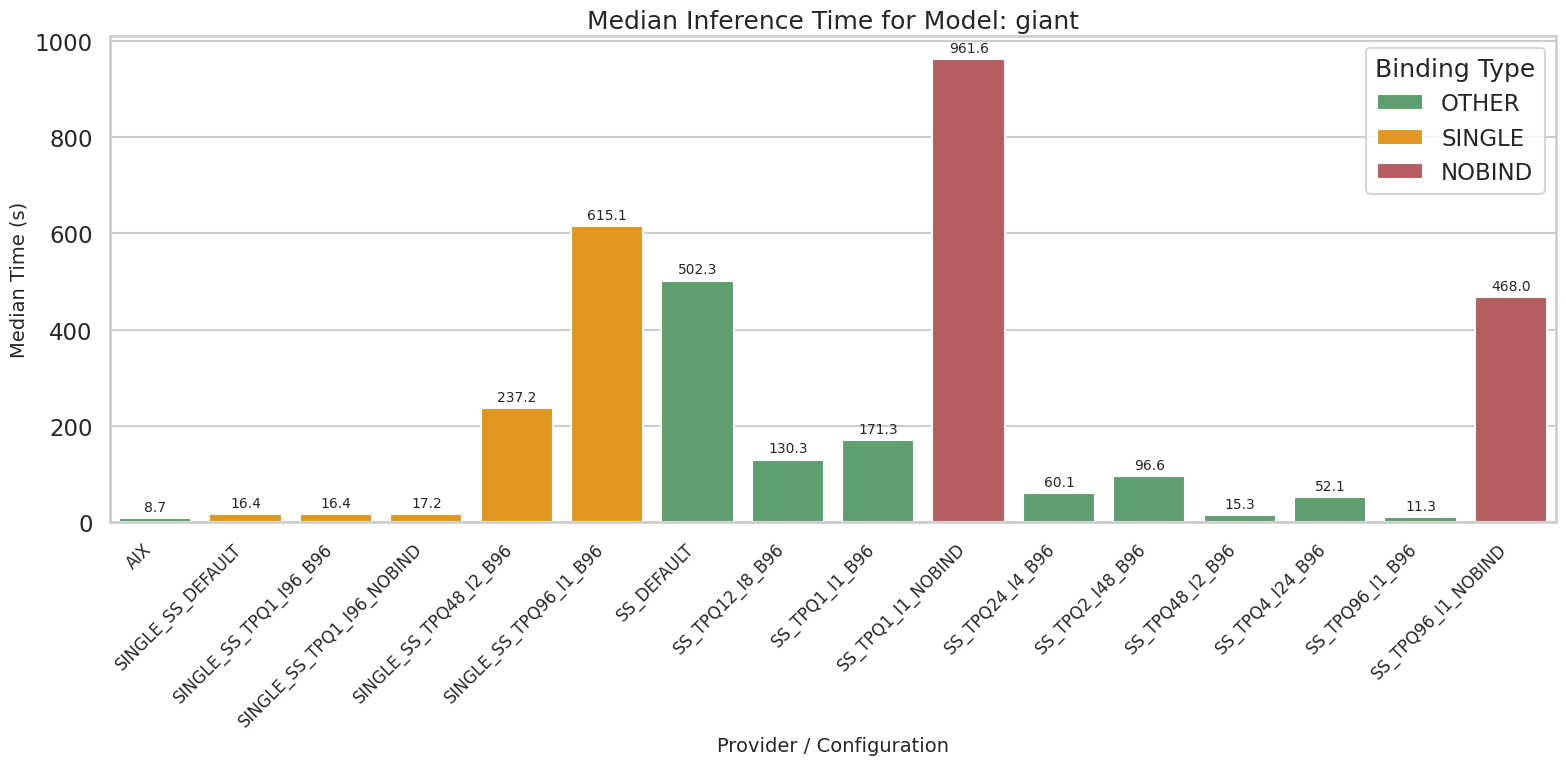

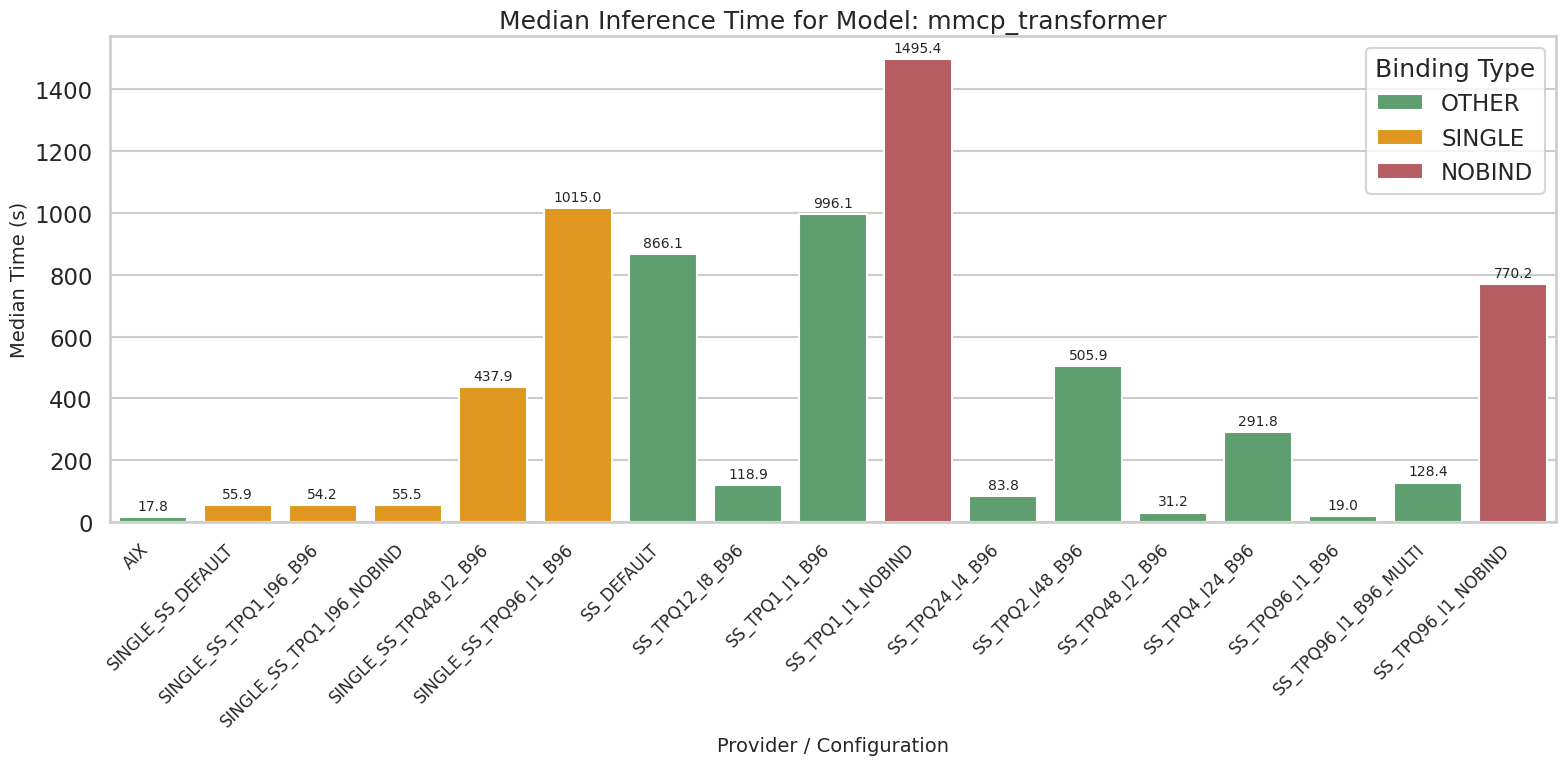

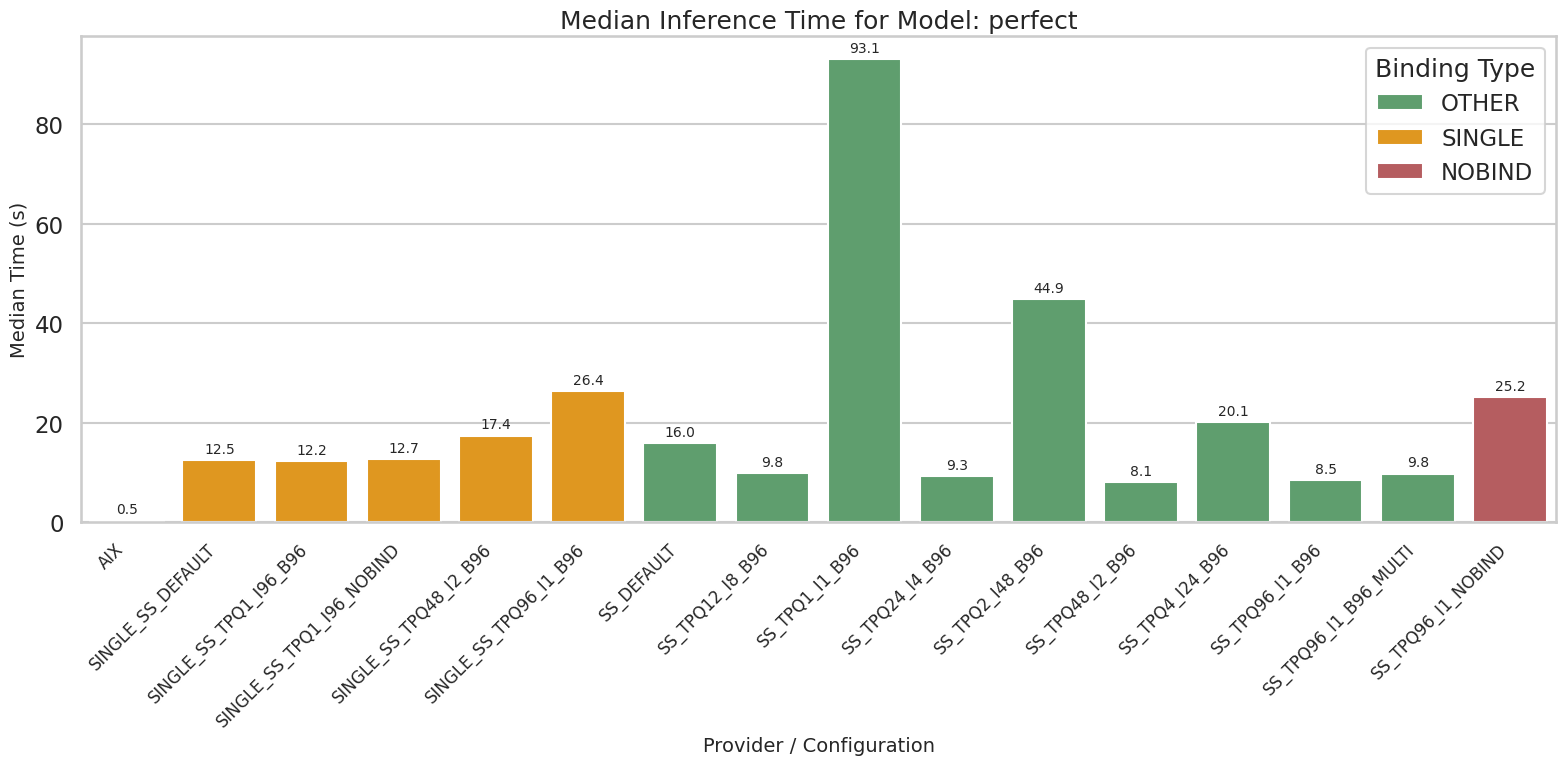

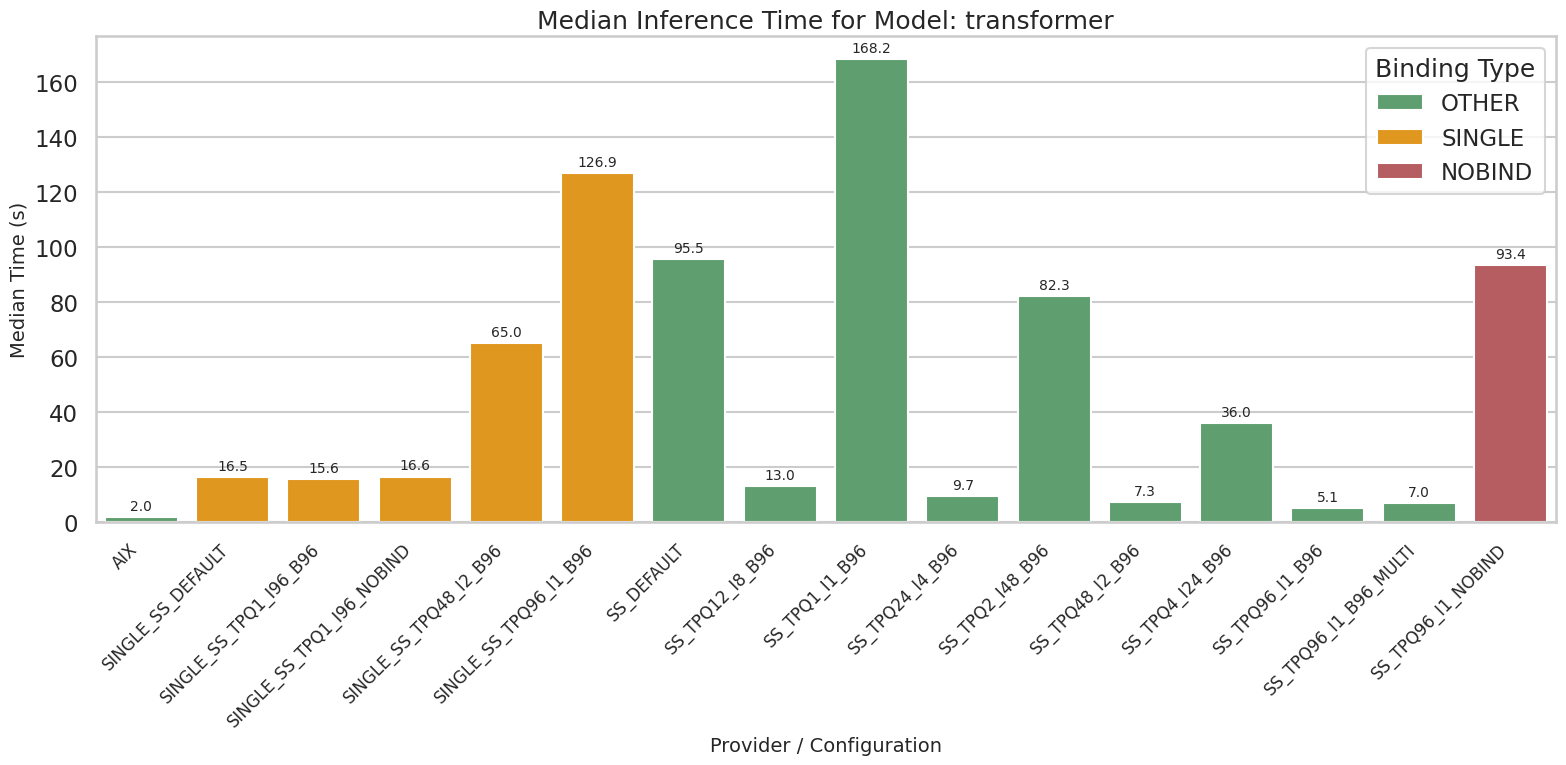

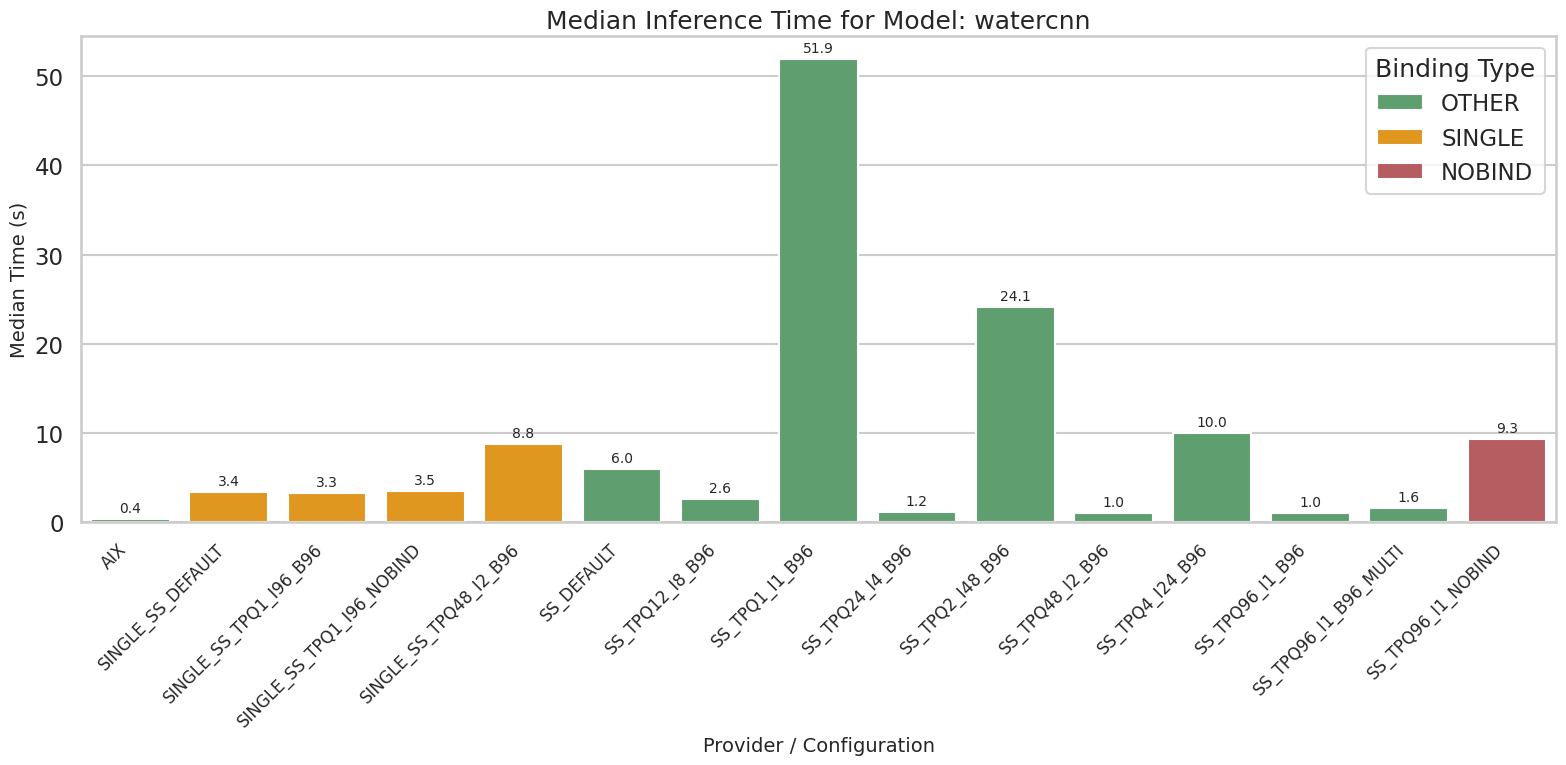

In [17]:
df_success = df[df['status'] == 'SUCCESS'].copy()

models = sorted(df_success['model'].unique())
palette = {"BIND": "#4C72B0", "NOBIND": "#C44E52", "OTHER": "#55A868", "SINGLE": "#FF9F00"}

# Sort providers logically so they are consistent across plots
def get_provider_order(df_s):
    return sorted(df_s['provider'].unique())

for model in models:
    data_m = df_success[df_success['model'] == model]
    order = get_provider_order(data_m)
    
    plt.figure(figsize=(16, 8))
    ax = sns.barplot(data=data_m, x='provider', y='time_s', hue='bind_type', 
                     palette=palette, estimator=np.median, order=order, dodge=False, errorbar=None)
    
    # Add value labels on top of the bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)
    
    plt.title(f"Median Inference Time for Model: {model}", fontsize=18)
    plt.ylabel("Median Time (s)", fontsize=14)
    plt.xlabel("Provider / Configuration", fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.legend(title="Binding Type")
    plt.tight_layout()
    plt.show()


## Variance and Confidence Intervals (Box Plots)
To accurately measure the stability of the 10 consecutive executions per configuration, these Box Plots map out the complete variance.
Whiskers are set to `whis=(2.5, 97.5)` to explicitly outline the **95% Confidence Interval** boundaries. Outliers (the 5% extremes) are rendered as individual diamonds.


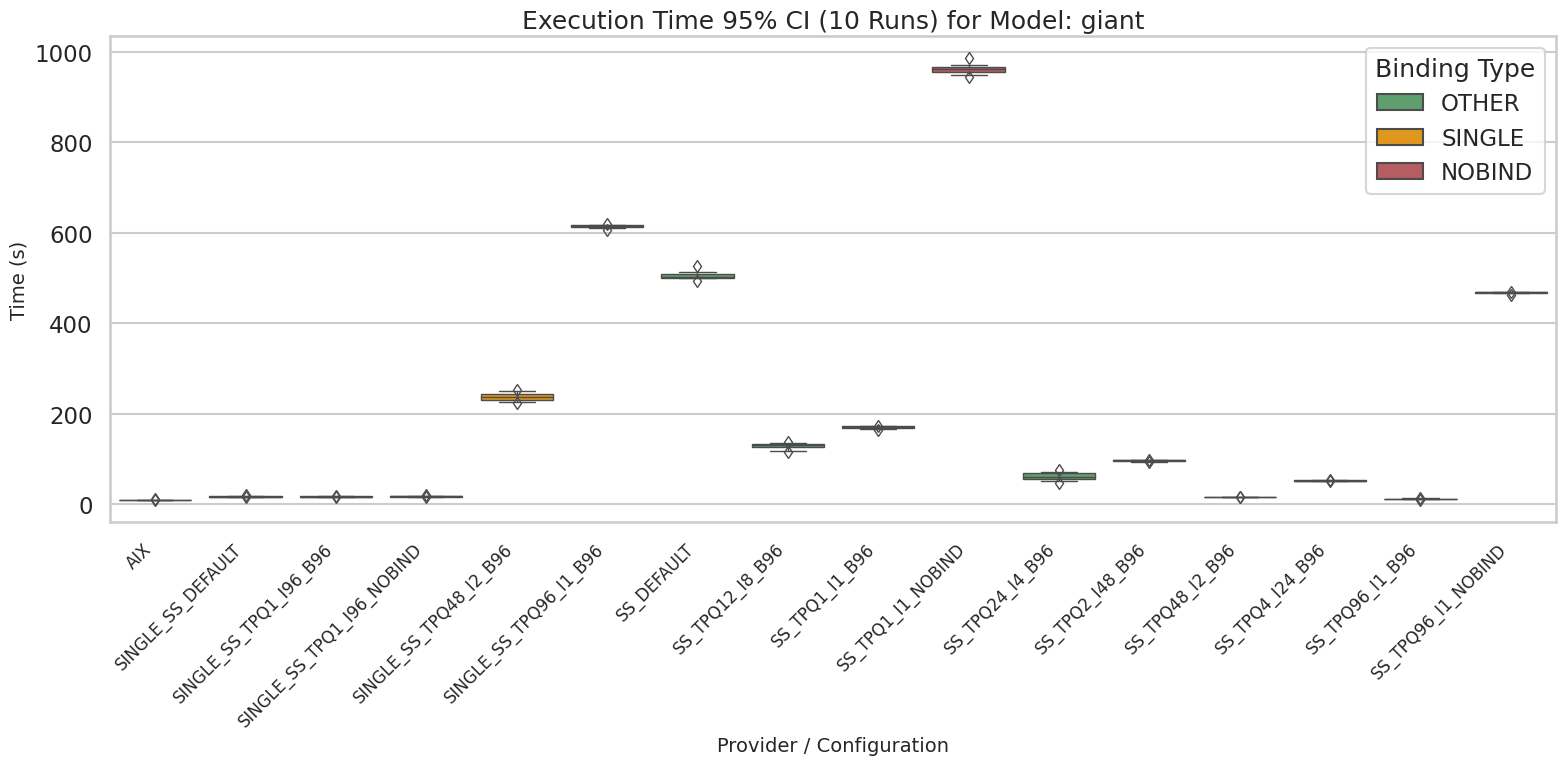

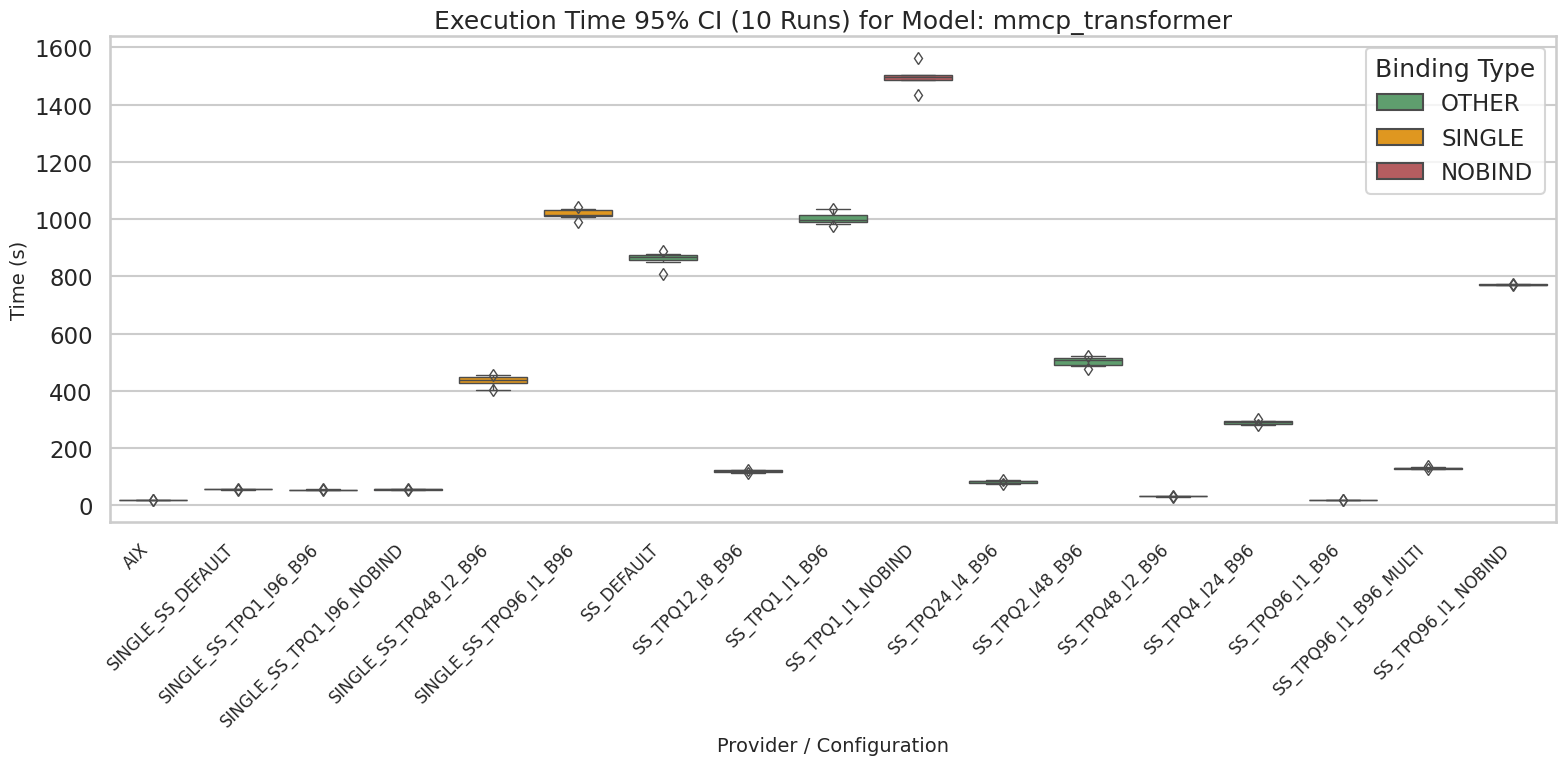

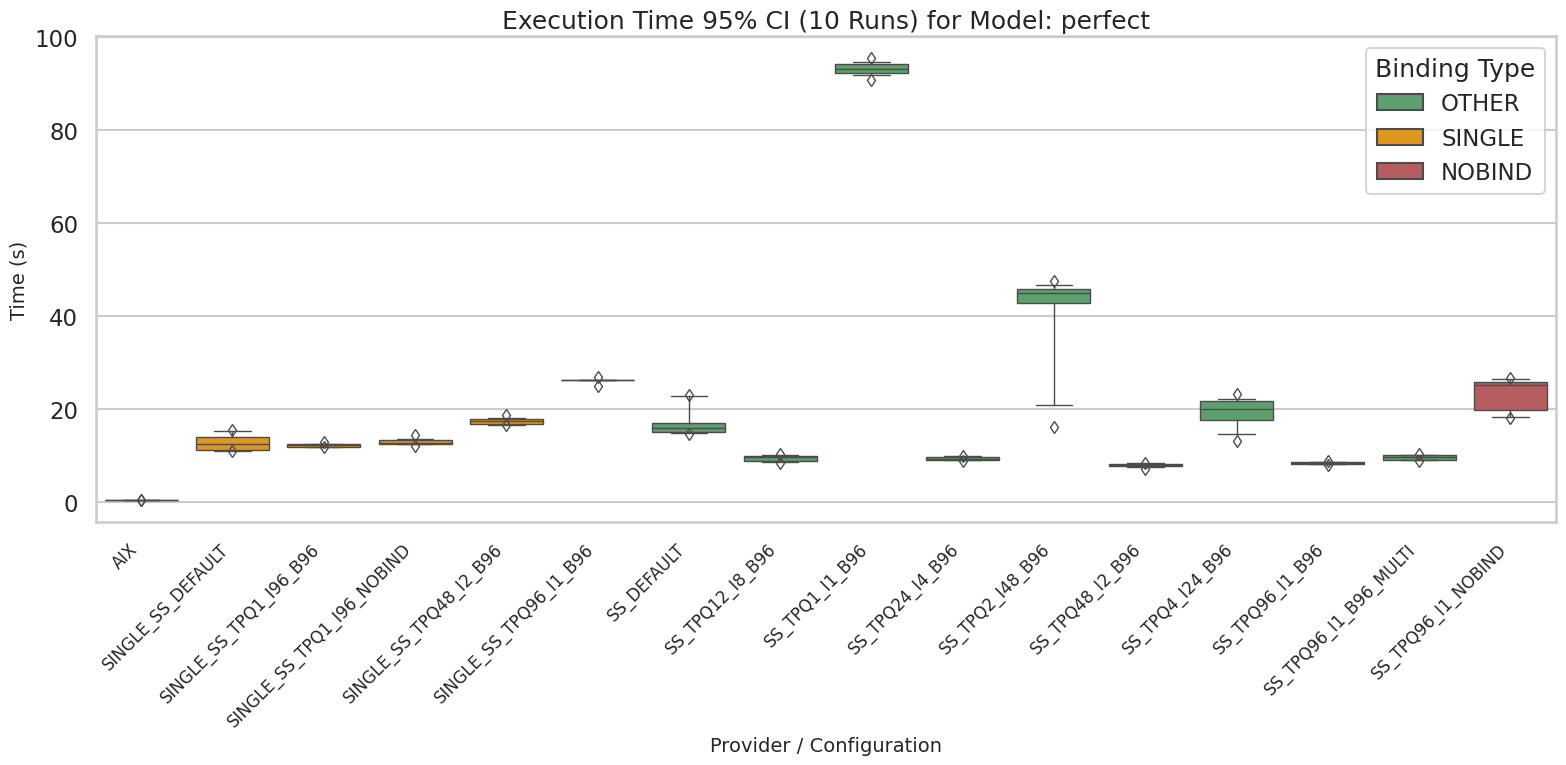

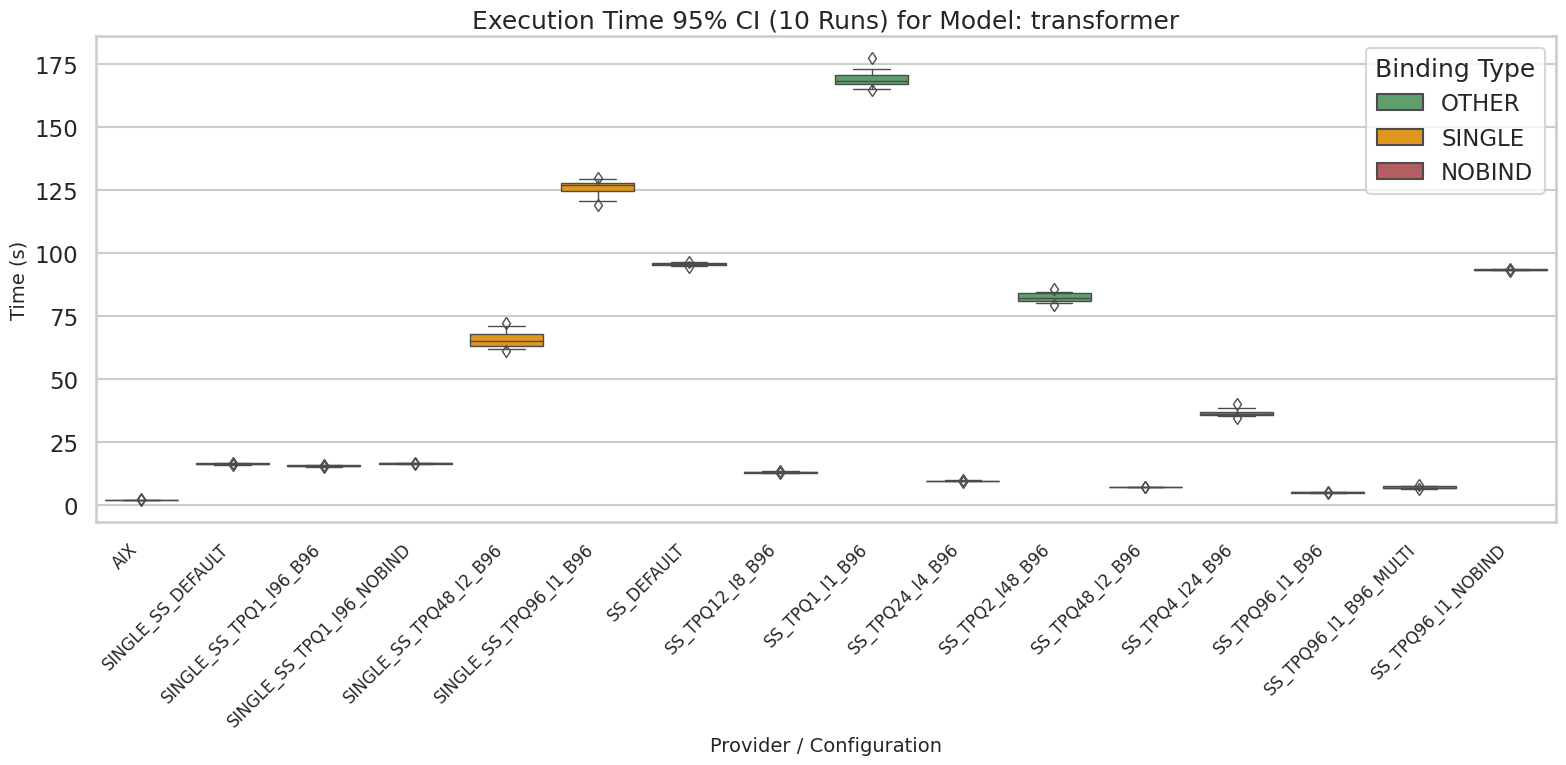

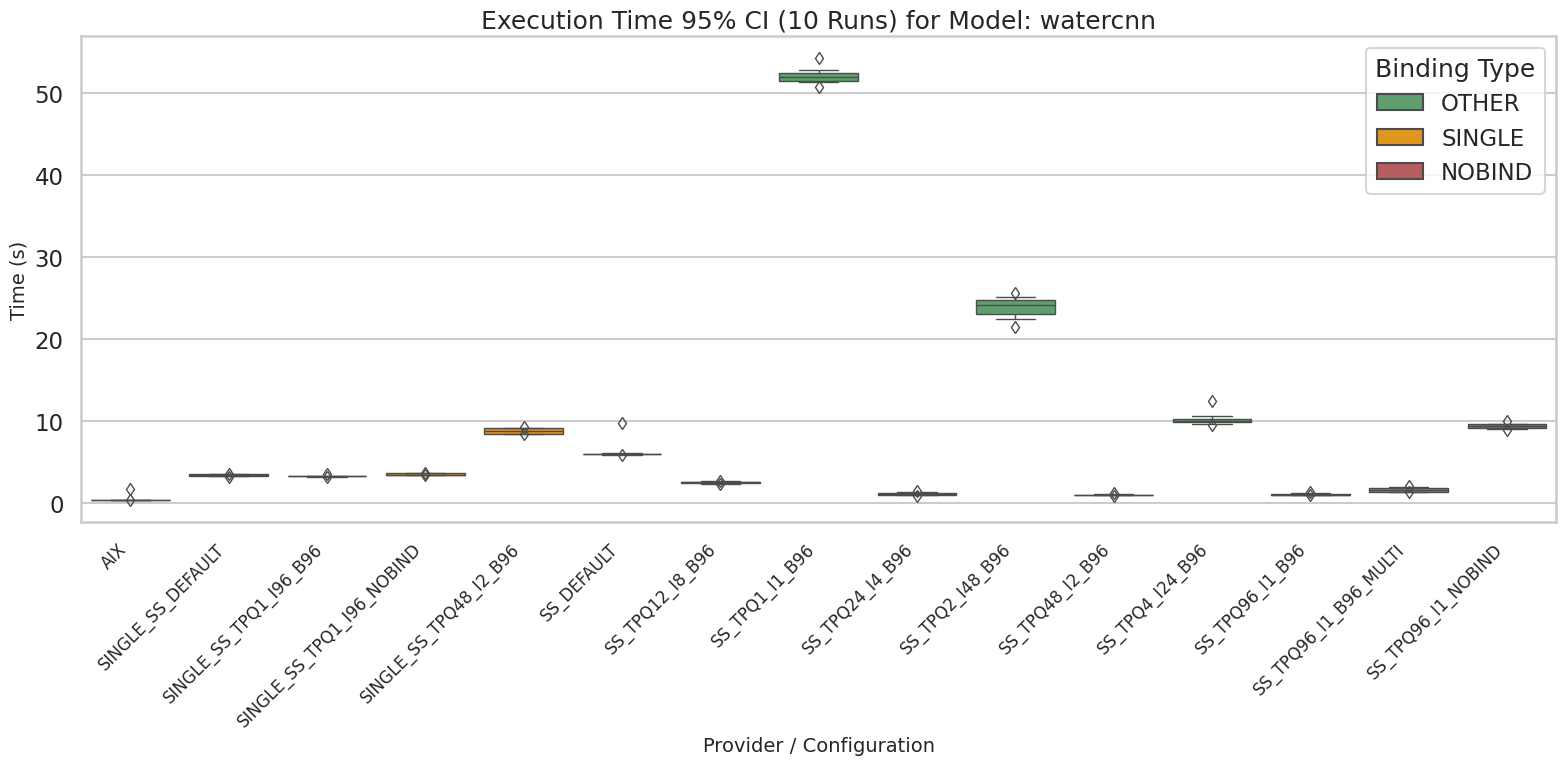

In [18]:
for model in models:
    data_m = df_success[df_success['model'] == model]
    order = get_provider_order(data_m)
    
    plt.figure(figsize=(16, 8))
    # whis=(2.5, 97.5) visualizes the 95% empirical confidence interval limits directly on the whiskers
    sns.boxplot(data=data_m, x='provider', y='time_s', hue='bind_type', 
                palette=palette, order=order, dodge=False, whis=(2.5, 97.5), fliersize=6, flierprops=dict(marker='d'))
    
    plt.title(f"Execution Time 95% CI (10 Runs) for Model: {model}", fontsize=18)
    plt.ylabel("Time (s)", fontsize=14)
    plt.xlabel("Provider / Configuration", fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.legend(title="Binding Type")
    plt.tight_layout()
    plt.show()


## Maximum RSS Memory (Bar Plots)
The bar plots depict the median maximum resident set size (Max RSS) in MB across all runs.

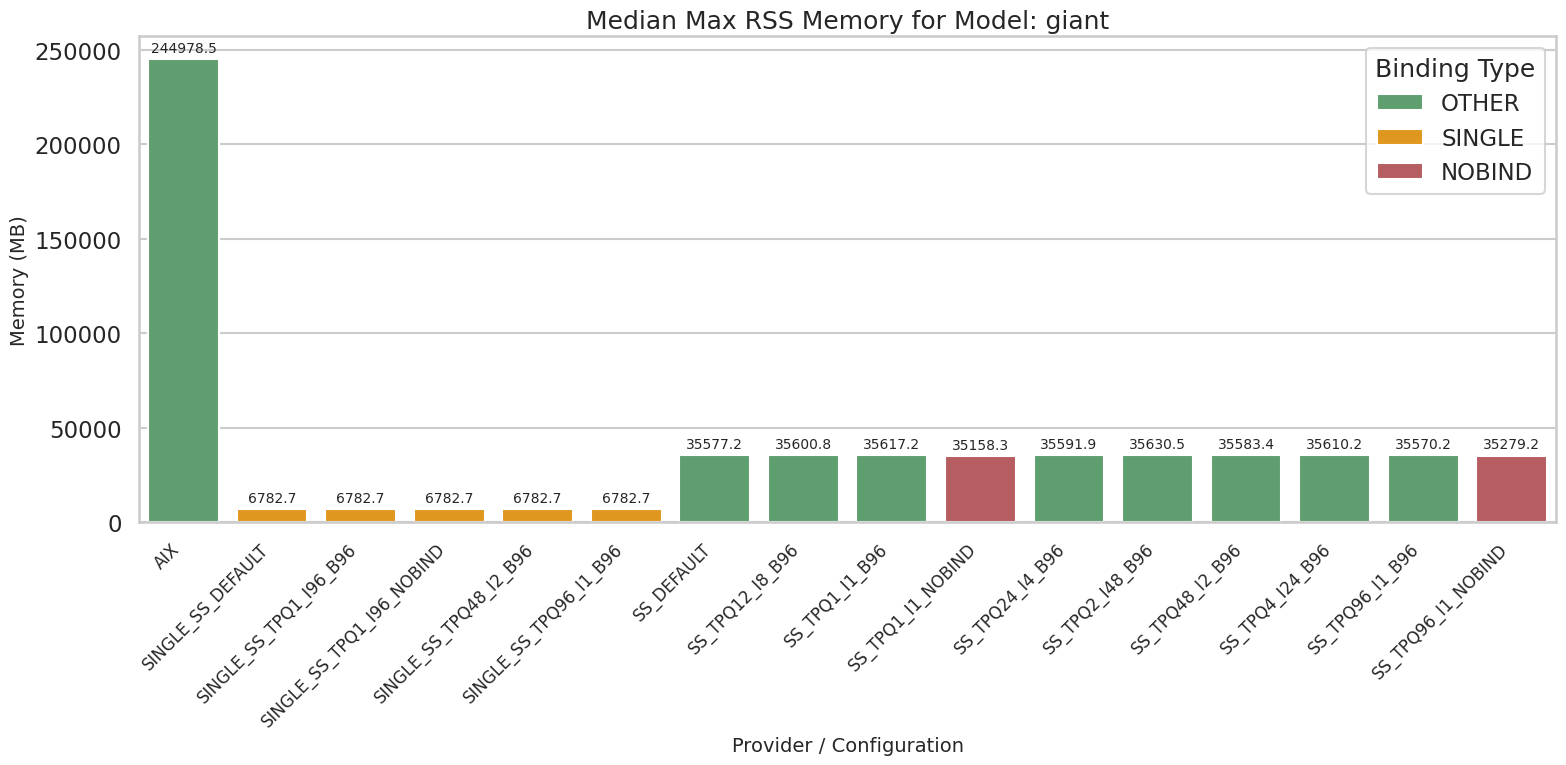

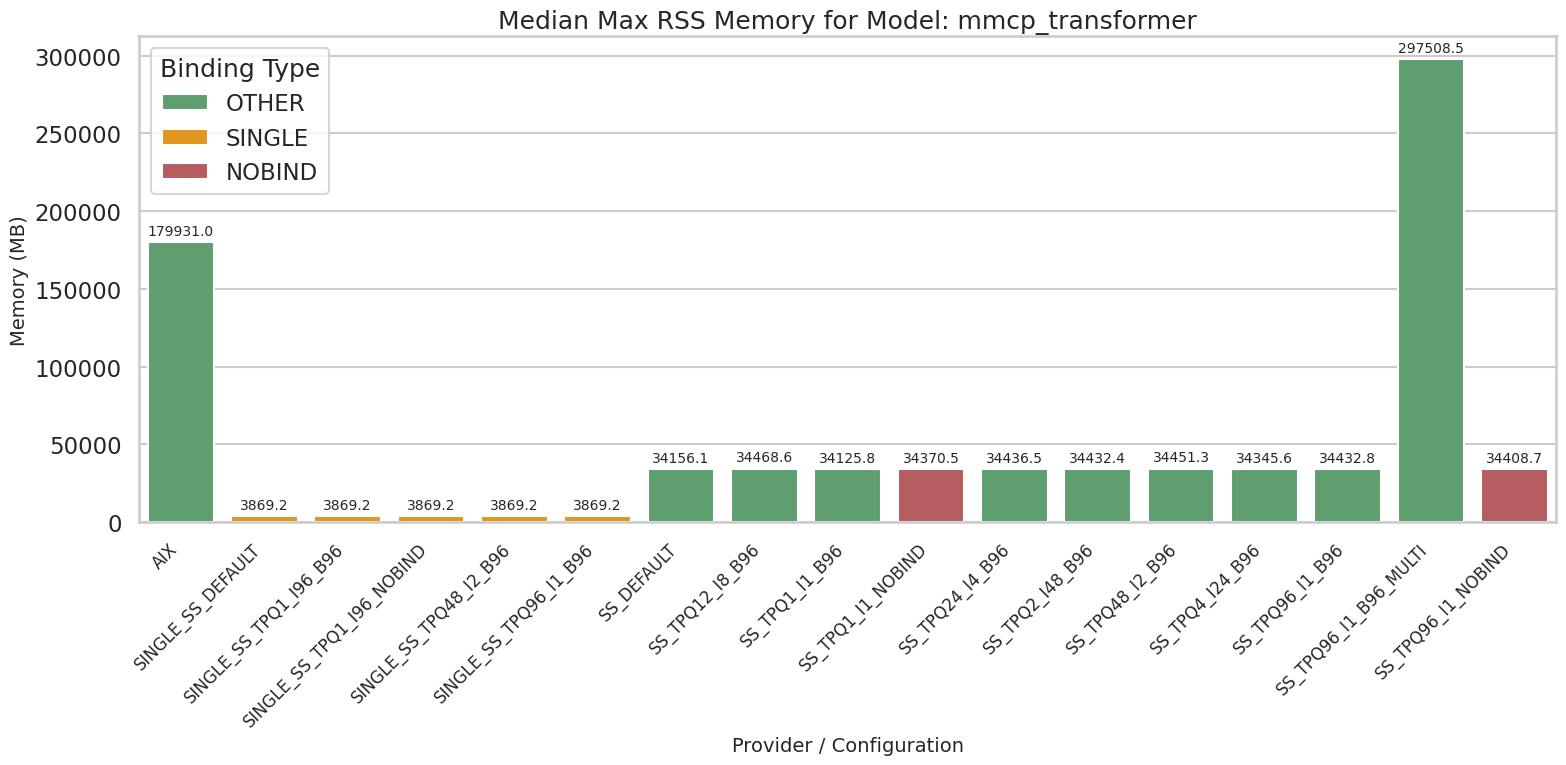

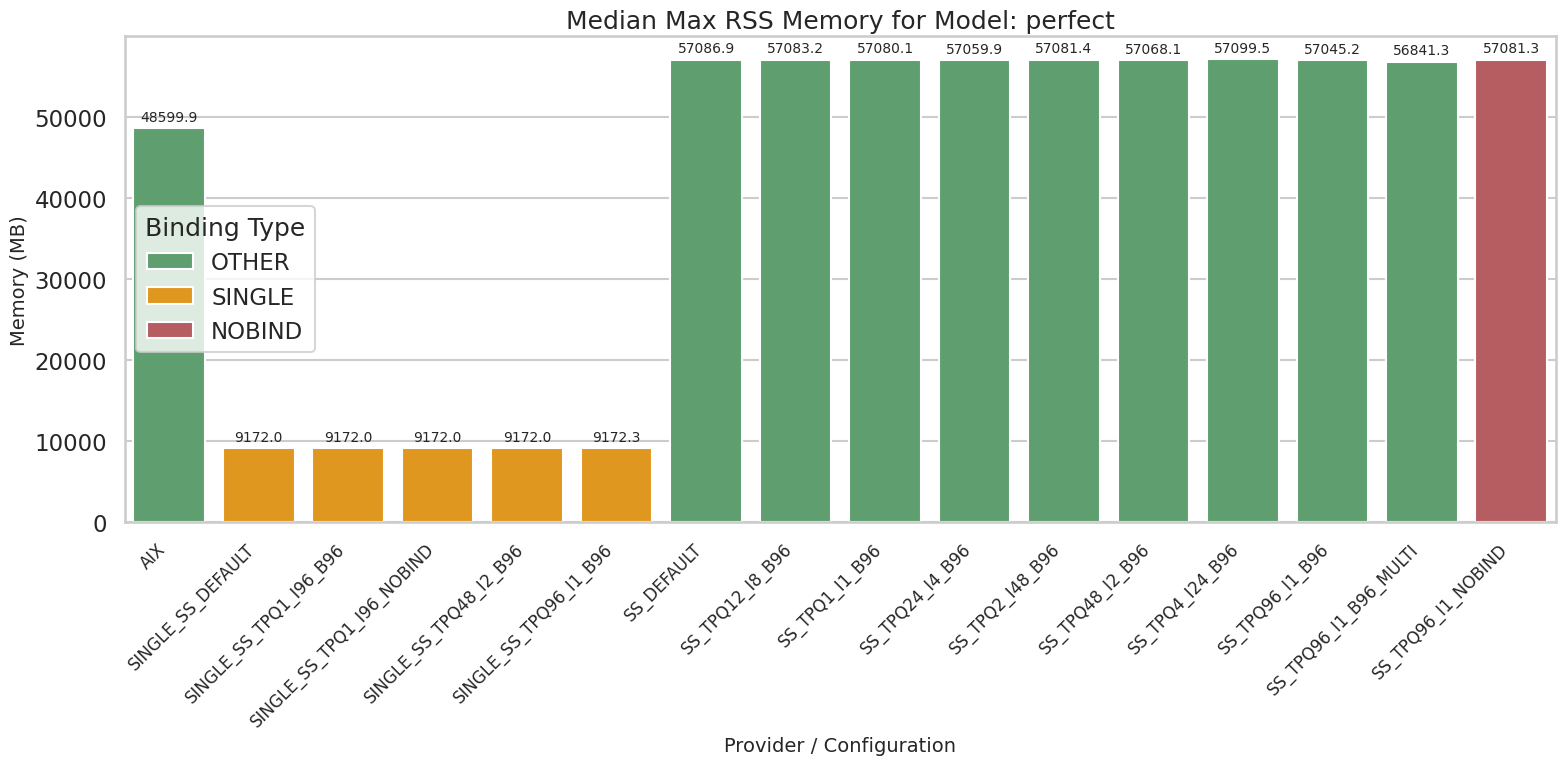

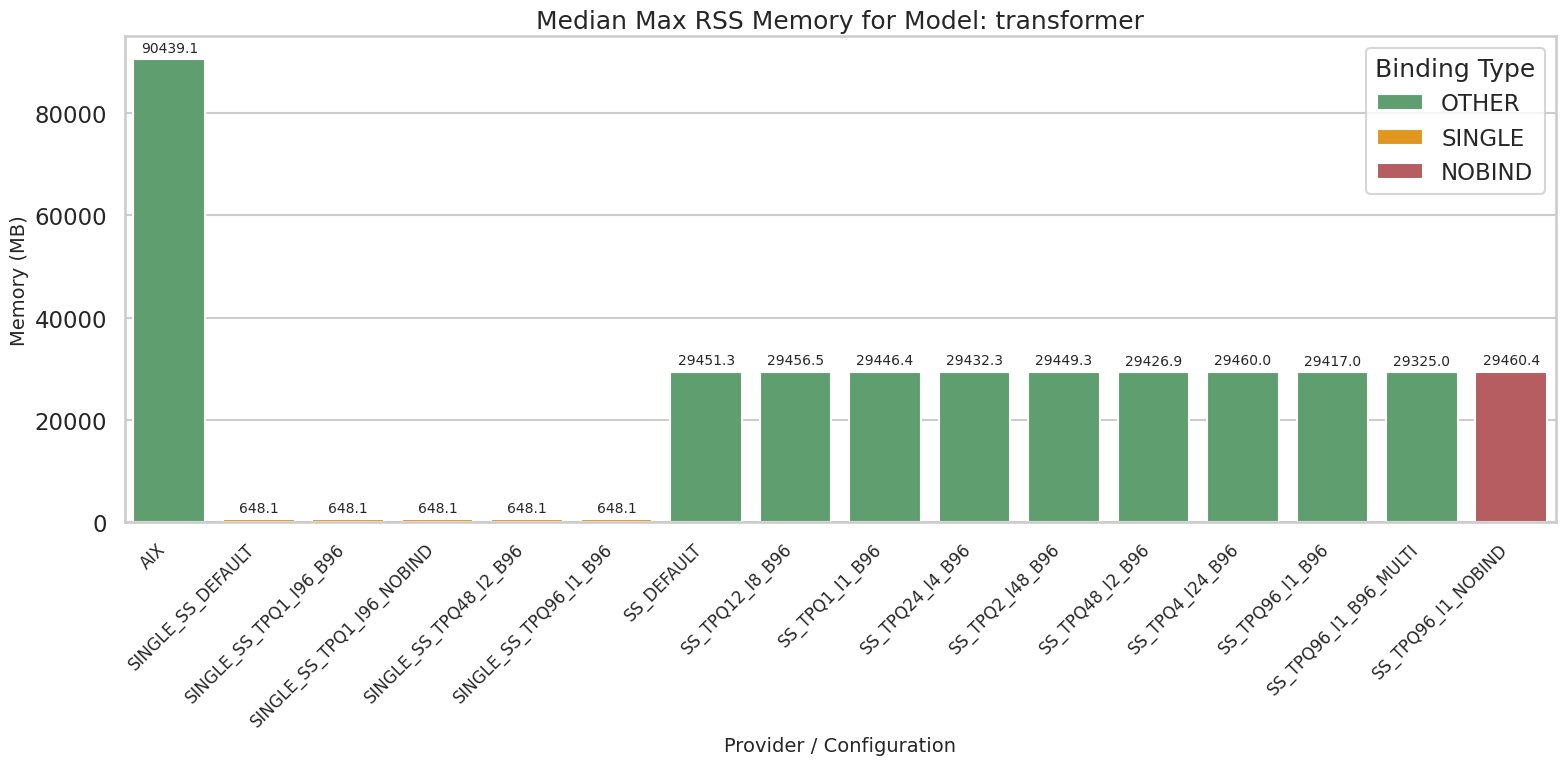

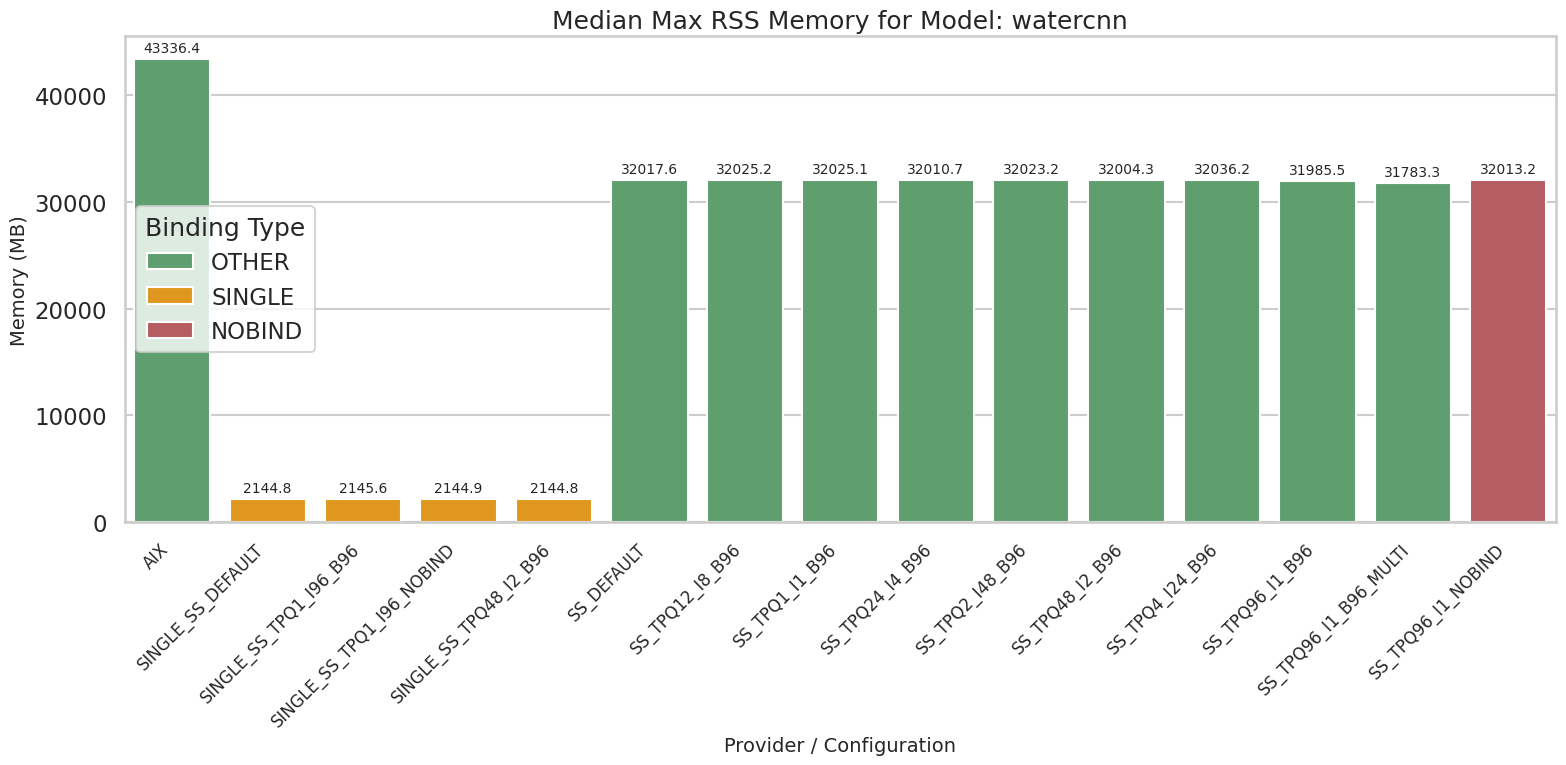

In [19]:
for model in models:
    data_m = df_success[df_success['model'] == model]
    order = get_provider_order(data_m)
    
    plt.figure(figsize=(16, 8))
    ax = sns.barplot(data=data_m, x='provider', y='max_rss_mb', hue='bind_type', 
                     palette=palette, estimator=np.median, order=order, dodge=False, errorbar=None)
    
    # Add value labels on top of the bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)
    
    plt.title(f"Median Max RSS Memory for Model: {model}", fontsize=18)
    plt.ylabel("Memory (MB)", fontsize=14)
    plt.xlabel("Provider / Configuration", fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.legend(title="Binding Type")
    plt.tight_layout()
    plt.show()


## Maximum RSS Memory Variance (Box Plots)
Box plots showing the 95% confidence variance of peak memory usage across consecutive inferences.

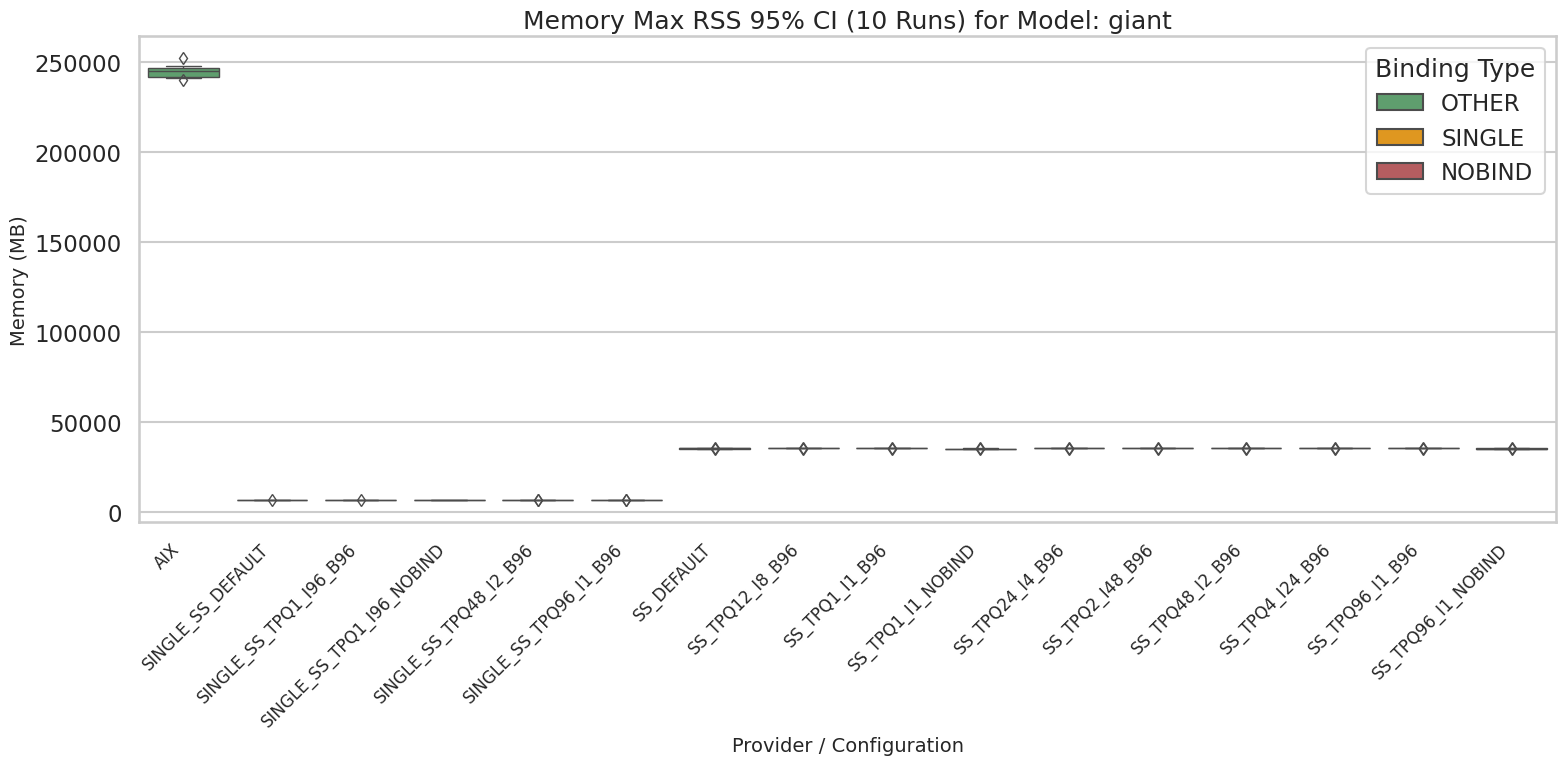

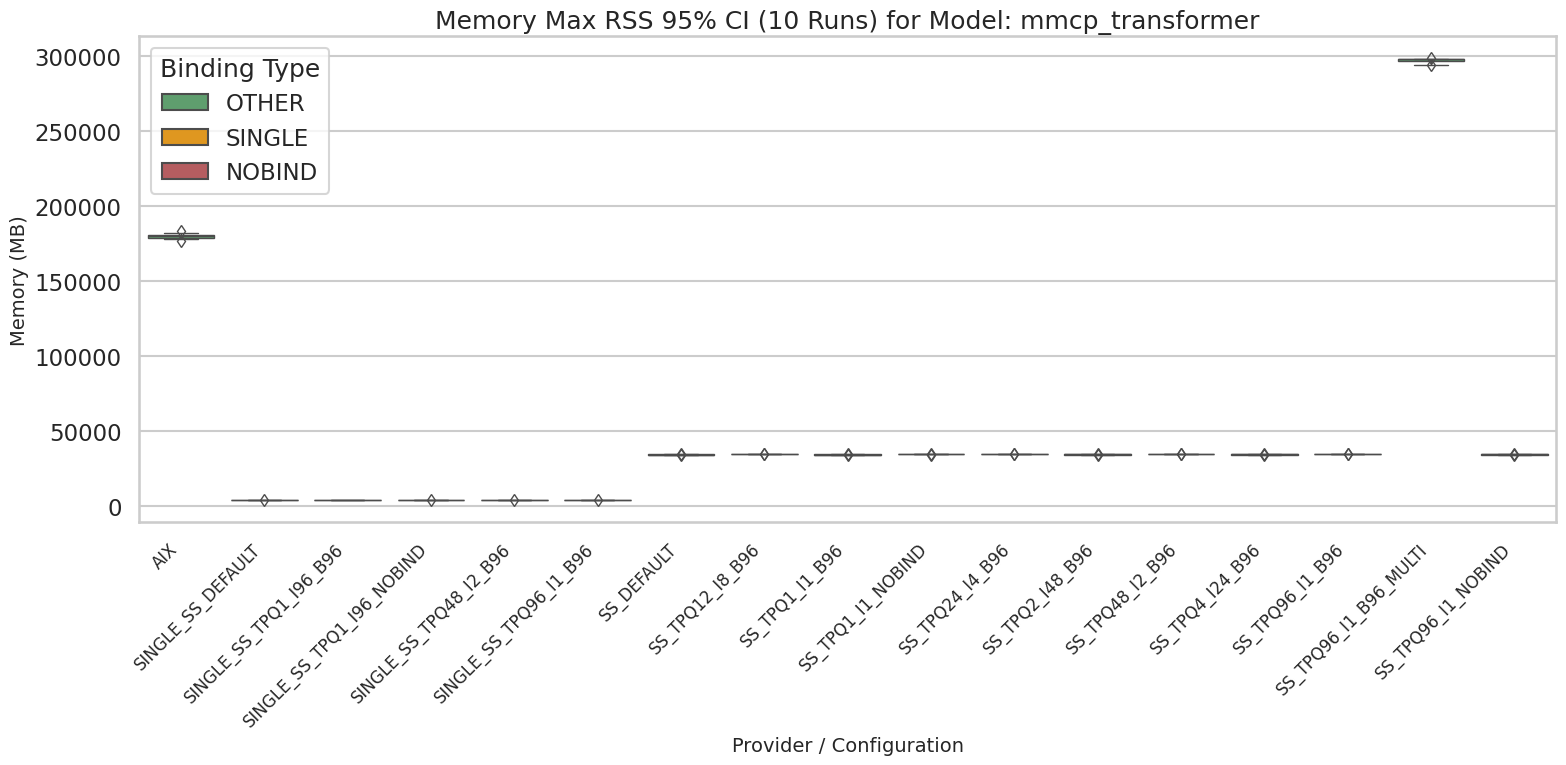

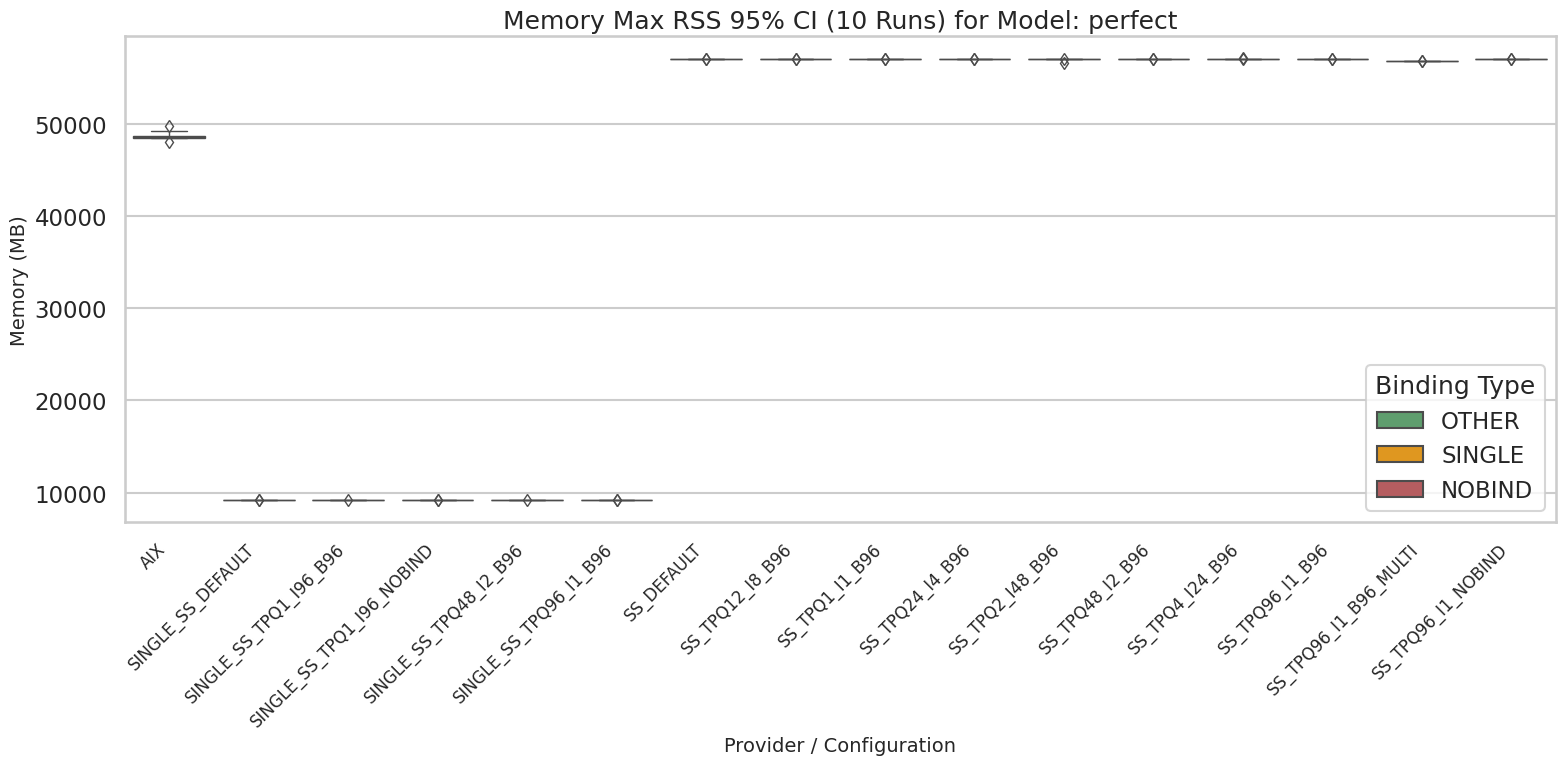

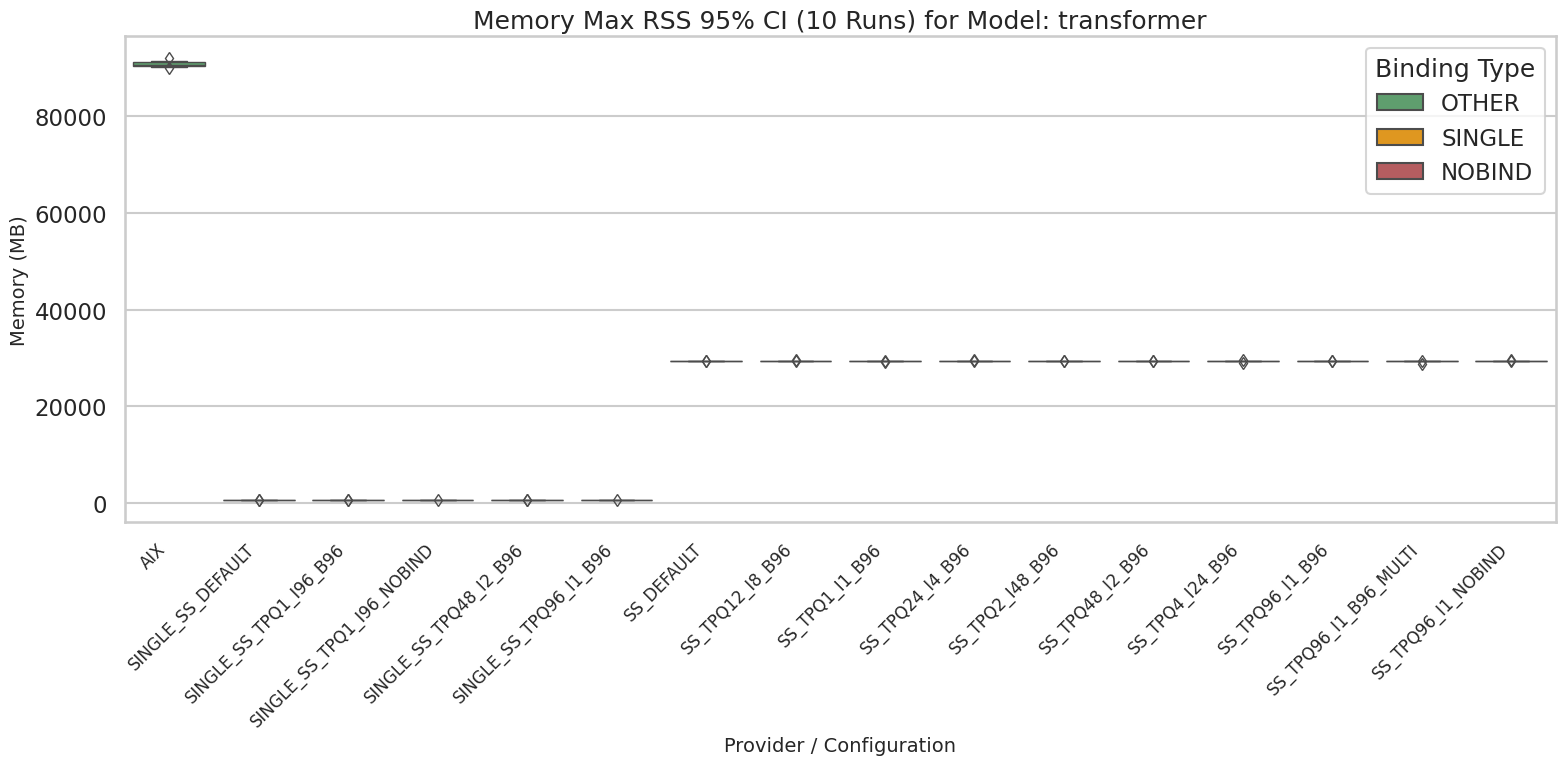

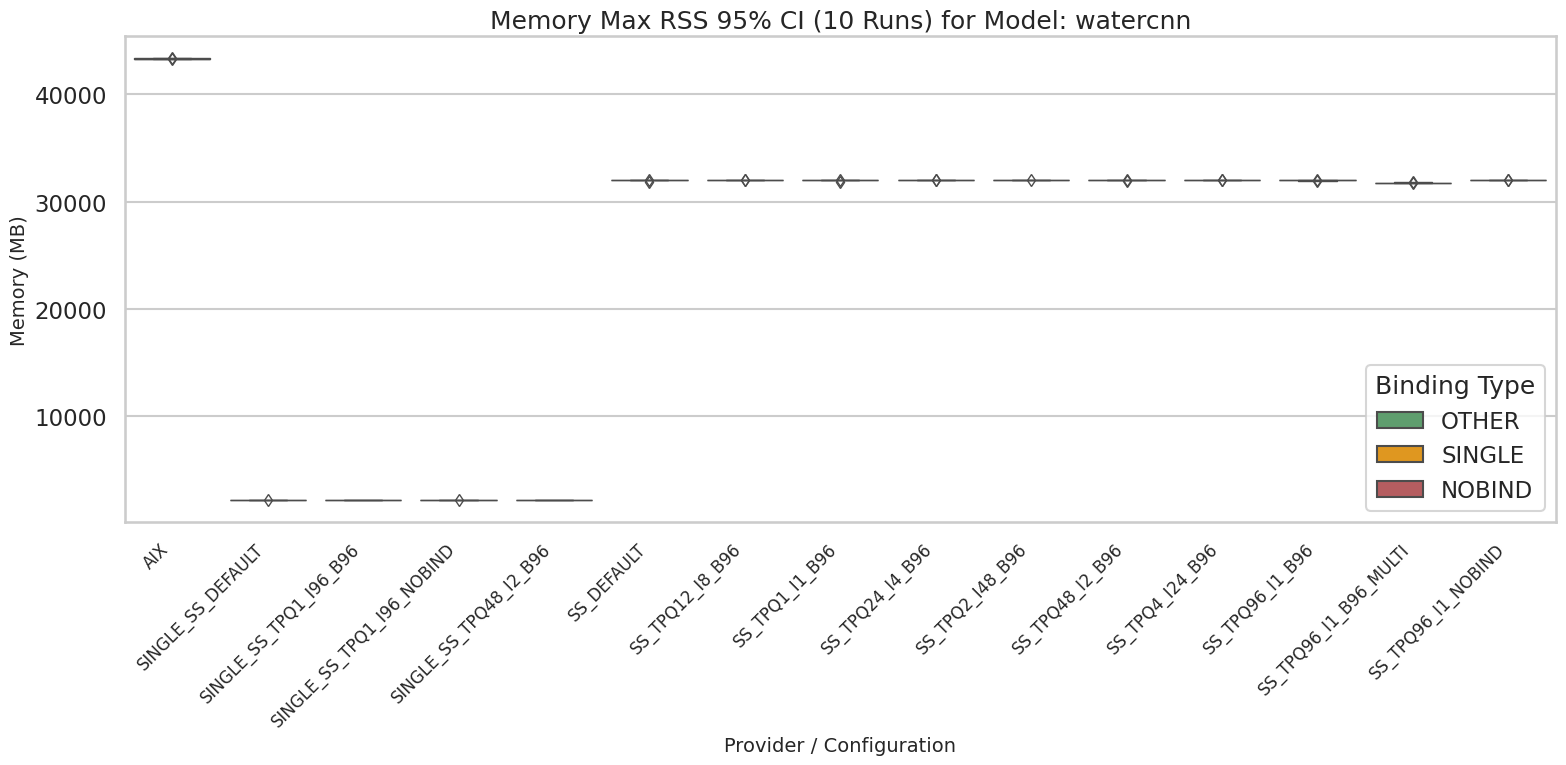

In [20]:
for model in models:
    data_m = df_success[df_success['model'] == model]
    order = get_provider_order(data_m)
    
    plt.figure(figsize=(16, 8))
    sns.boxplot(data=data_m, x='provider', y='max_rss_mb', hue='bind_type', 
                palette=palette, order=order, dodge=False, whis=(2.5, 97.5), fliersize=6, flierprops=dict(marker='d'))
    
    plt.title(f"Memory Max RSS 95% CI (10 Runs) for Model: {model}", fontsize=18)
    plt.ylabel("Memory (MB)", fontsize=14)
    plt.xlabel("Provider / Configuration", fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.legend(title="Binding Type")
    plt.tight_layout()
    plt.show()
